<a href="https://colab.research.google.com/github/DebroopDattz/ABCD/blob/main/MuleAccountDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏦 Bank of India — Mule Account Detection System

## Problem Statement
Banks are facing a growing number of cyber-enabled financial frauds involving **mule accounts** used to receive, transfer, and conceal fraudulent funds across multiple banking channels. Traditional rule-based monitoring systems often fail to identify evolving fraud patterns in real time.

## Objective
Build an AI/ML classification system capable of identifying suspicious and mule accounts by:
1. **Feature Engineering** — extract the most predictive features from the dataset
2. **Model Training** — train an XGBoost classifier with SMOTE oversampling to handle class imbalance
3. **Evaluation** — measure precision, recall, F1-score, and ROC-AUC
4. **Risk Scoring** — assign probability-based risk levels (Low / Medium / High) to each account
5. **Explainability** — use SHAP values to interpret model decisions

> **Target variable**: `F3924` (1 = suspicious / mule account, 0 = legitimate)

### Key Bank-specified Features
`F115, F321, F527, F531, F670, F1692, F2082, F2122, F2582, F2678, F2737, F2956, F3043, F3836, F3887, F3889, F3891, F3894`

## 📦 Step 1 — Install & Import Libraries

In [6]:
# Install required packages (run once)
import subprocess, sys

packages = [
    'xgboost',
    'imbalanced-learn',
    'shap',
    'scikit-learn',
    'pandas',
    'numpy',
    'matplotlib',
    'seaborn',
    'joblib'
]

for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('✅ All packages installed successfully.')

✅ All packages installed successfully.


In [7]:
import os
import re
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
import shap

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

print('✅ Libraries imported successfully.')
print(f'   NumPy: {np.__version__}')
print(f'   Pandas: {pd.__version__}')

✅ Libraries imported successfully.
   NumPy: 2.0.2
   Pandas: 2.2.2


## 📂 Step 2 — Load Dataset

In [8]:
# ── Configure path ───────────────────────────────────────────────────────────
# If running locally, set DATA_PATH to the absolute path of DataSet.csv
# If running on Google Colab, upload the file directly or mount Drive and update the path accordingly.

import os
import pandas as pd

# Try to load from Google Colab's default upload directory first.
DATA_PATH = 'DataSet.csv'

if not os.path.exists(DATA_PATH):
    try:
        # Attempt to upload file if not found
        from google.colab import files
        print("\n'DataSet.csv' not found. Please upload the file.")
        uploaded = files.upload()
        if 'DataSet.csv' in uploaded:
            print("DataSet.csv uploaded successfully.")
        else:
            print("Failed to upload DataSet.csv. Please ensure you upload the correct file.")
            # Fallback to check if it was uploaded to MyDrive
            COLAB_DRIVE_PATH = '/content/drive/MyDrive/DataSet.csv'
            if os.path.exists(COLAB_DRIVE_PATH):
                DATA_PATH = COLAB_DRIVE_PATH
                print(f"Found DataSet.csv in Google Drive at {DATA_PATH}")
            else:
                raise FileNotFoundError("DataSet.csv not found locally, in Colab uploads, or in Google Drive.")
    except ImportError:
        # Not in Colab, fall back to local path logic if initial DATA_PATH failed
        LOCAL_PATH = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'DataSet.csv')
        if os.path.exists(LOCAL_PATH):
            DATA_PATH = LOCAL_PATH
        else:
            raise FileNotFoundError("DataSet.csv not found in local path.")

print(f'Loading data from: {DATA_PATH}')

TARGET = 'F3924'

df_raw = pd.read_csv(DATA_PATH)

print(f'\n{"=" * 60}')
print('DATASET OVERVIEW')
print(f'{"=" * 60}')
print(f'Shape         : {df_raw.shape}')
print(f'Target column : {TARGET}')
print(f'Fraud ratio   : {df_raw[TARGET].mean():.4%}')
print(f'\nTarget distribution:')
print(df_raw[TARGET].value_counts())
print(f'\nData types:')
print(df_raw.dtypes.value_counts())
df_raw.head()


'DataSet.csv' not found. Please upload the file.


Saving DataSet.csv to DataSet.csv
DataSet.csv uploaded successfully.
Loading data from: DataSet.csv

DATASET OVERVIEW
Shape         : (9082, 3925)
Target column : F3924
Fraud ratio   : 0.8919%

Target distribution:
F3924
0    9001
1      81
Name: count, dtype: int64

Data types:
float64    3876
int64        41
object        8
Name: count, dtype: int64


,Unnamed: 0,F1,F2,F3,F4,F5,F6,F7,F8,F9,...,F3915,F3916,F3917,F3918,F3919,F3920,F3921,F3922,F3923,F3924
0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,1,0,0,1,0,0,1,0,0
1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,1,0,0,1,0,1,0,0,0
2,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,1,0,0,1,0,0,1,0,0
3,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,1,0,0,1,0,0,1,0,0
4,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,1,0,0,1,0,1,0,0,0


## 🔍 Step 3 — Exploratory Data Analysis (EDA)

Columns with missing values: 3835
Columns fully populated   : 90


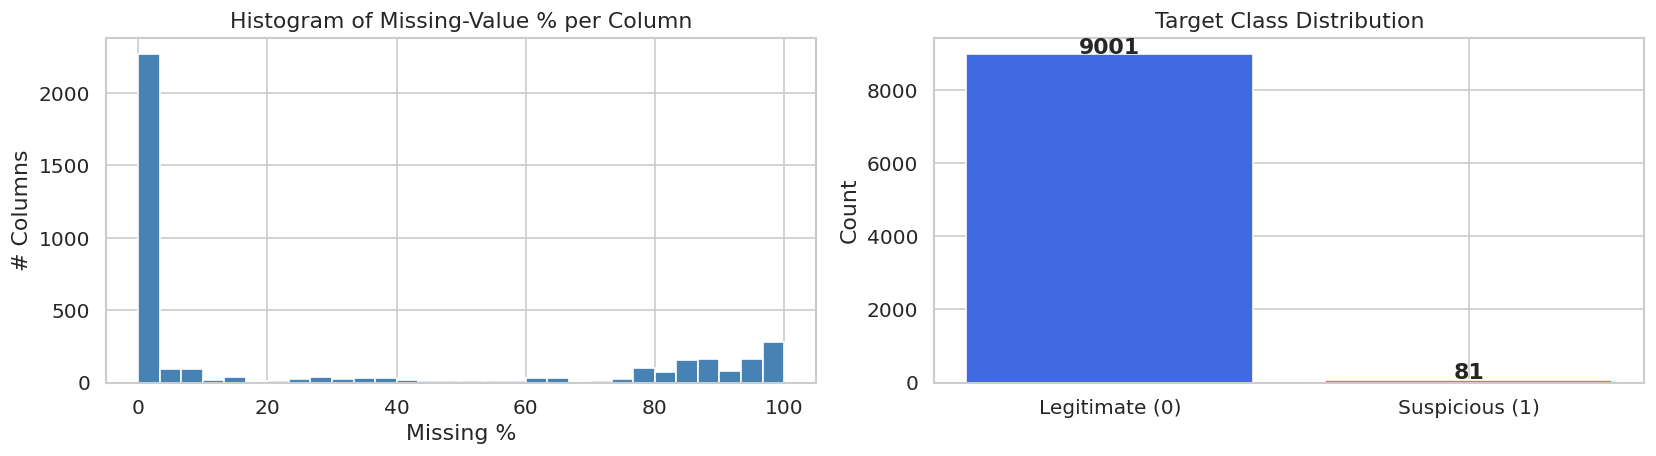

In [9]:
# ── 3a. Missing-value analysis ────────────────────────────────────────────────
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_summary = pd.DataFrame({'Missing': missing, 'Missing_%': missing_pct})
missing_summary = missing_summary[missing_summary['Missing'] > 0].sort_values('Missing_%', ascending=False)

print(f'Columns with missing values: {len(missing_summary)}')
print(f'Columns fully populated   : {df_raw.shape[1] - len(missing_summary)}')

# Distribution of missingness
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(missing_pct[missing_pct > 0], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Histogram of Missing-Value % per Column')
axes[0].set_xlabel('Missing %')
axes[0].set_ylabel('# Columns')

# Target class distribution
counts = df_raw[TARGET].value_counts()
axes[1].bar(['Legitimate (0)', 'Suspicious (1)'], counts.values, color=['royalblue', 'tomato'])
axes[1].set_title('Target Class Distribution')
axes[1].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[1].text(i, v + 20, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

Bank-specified features available: 18 / 18


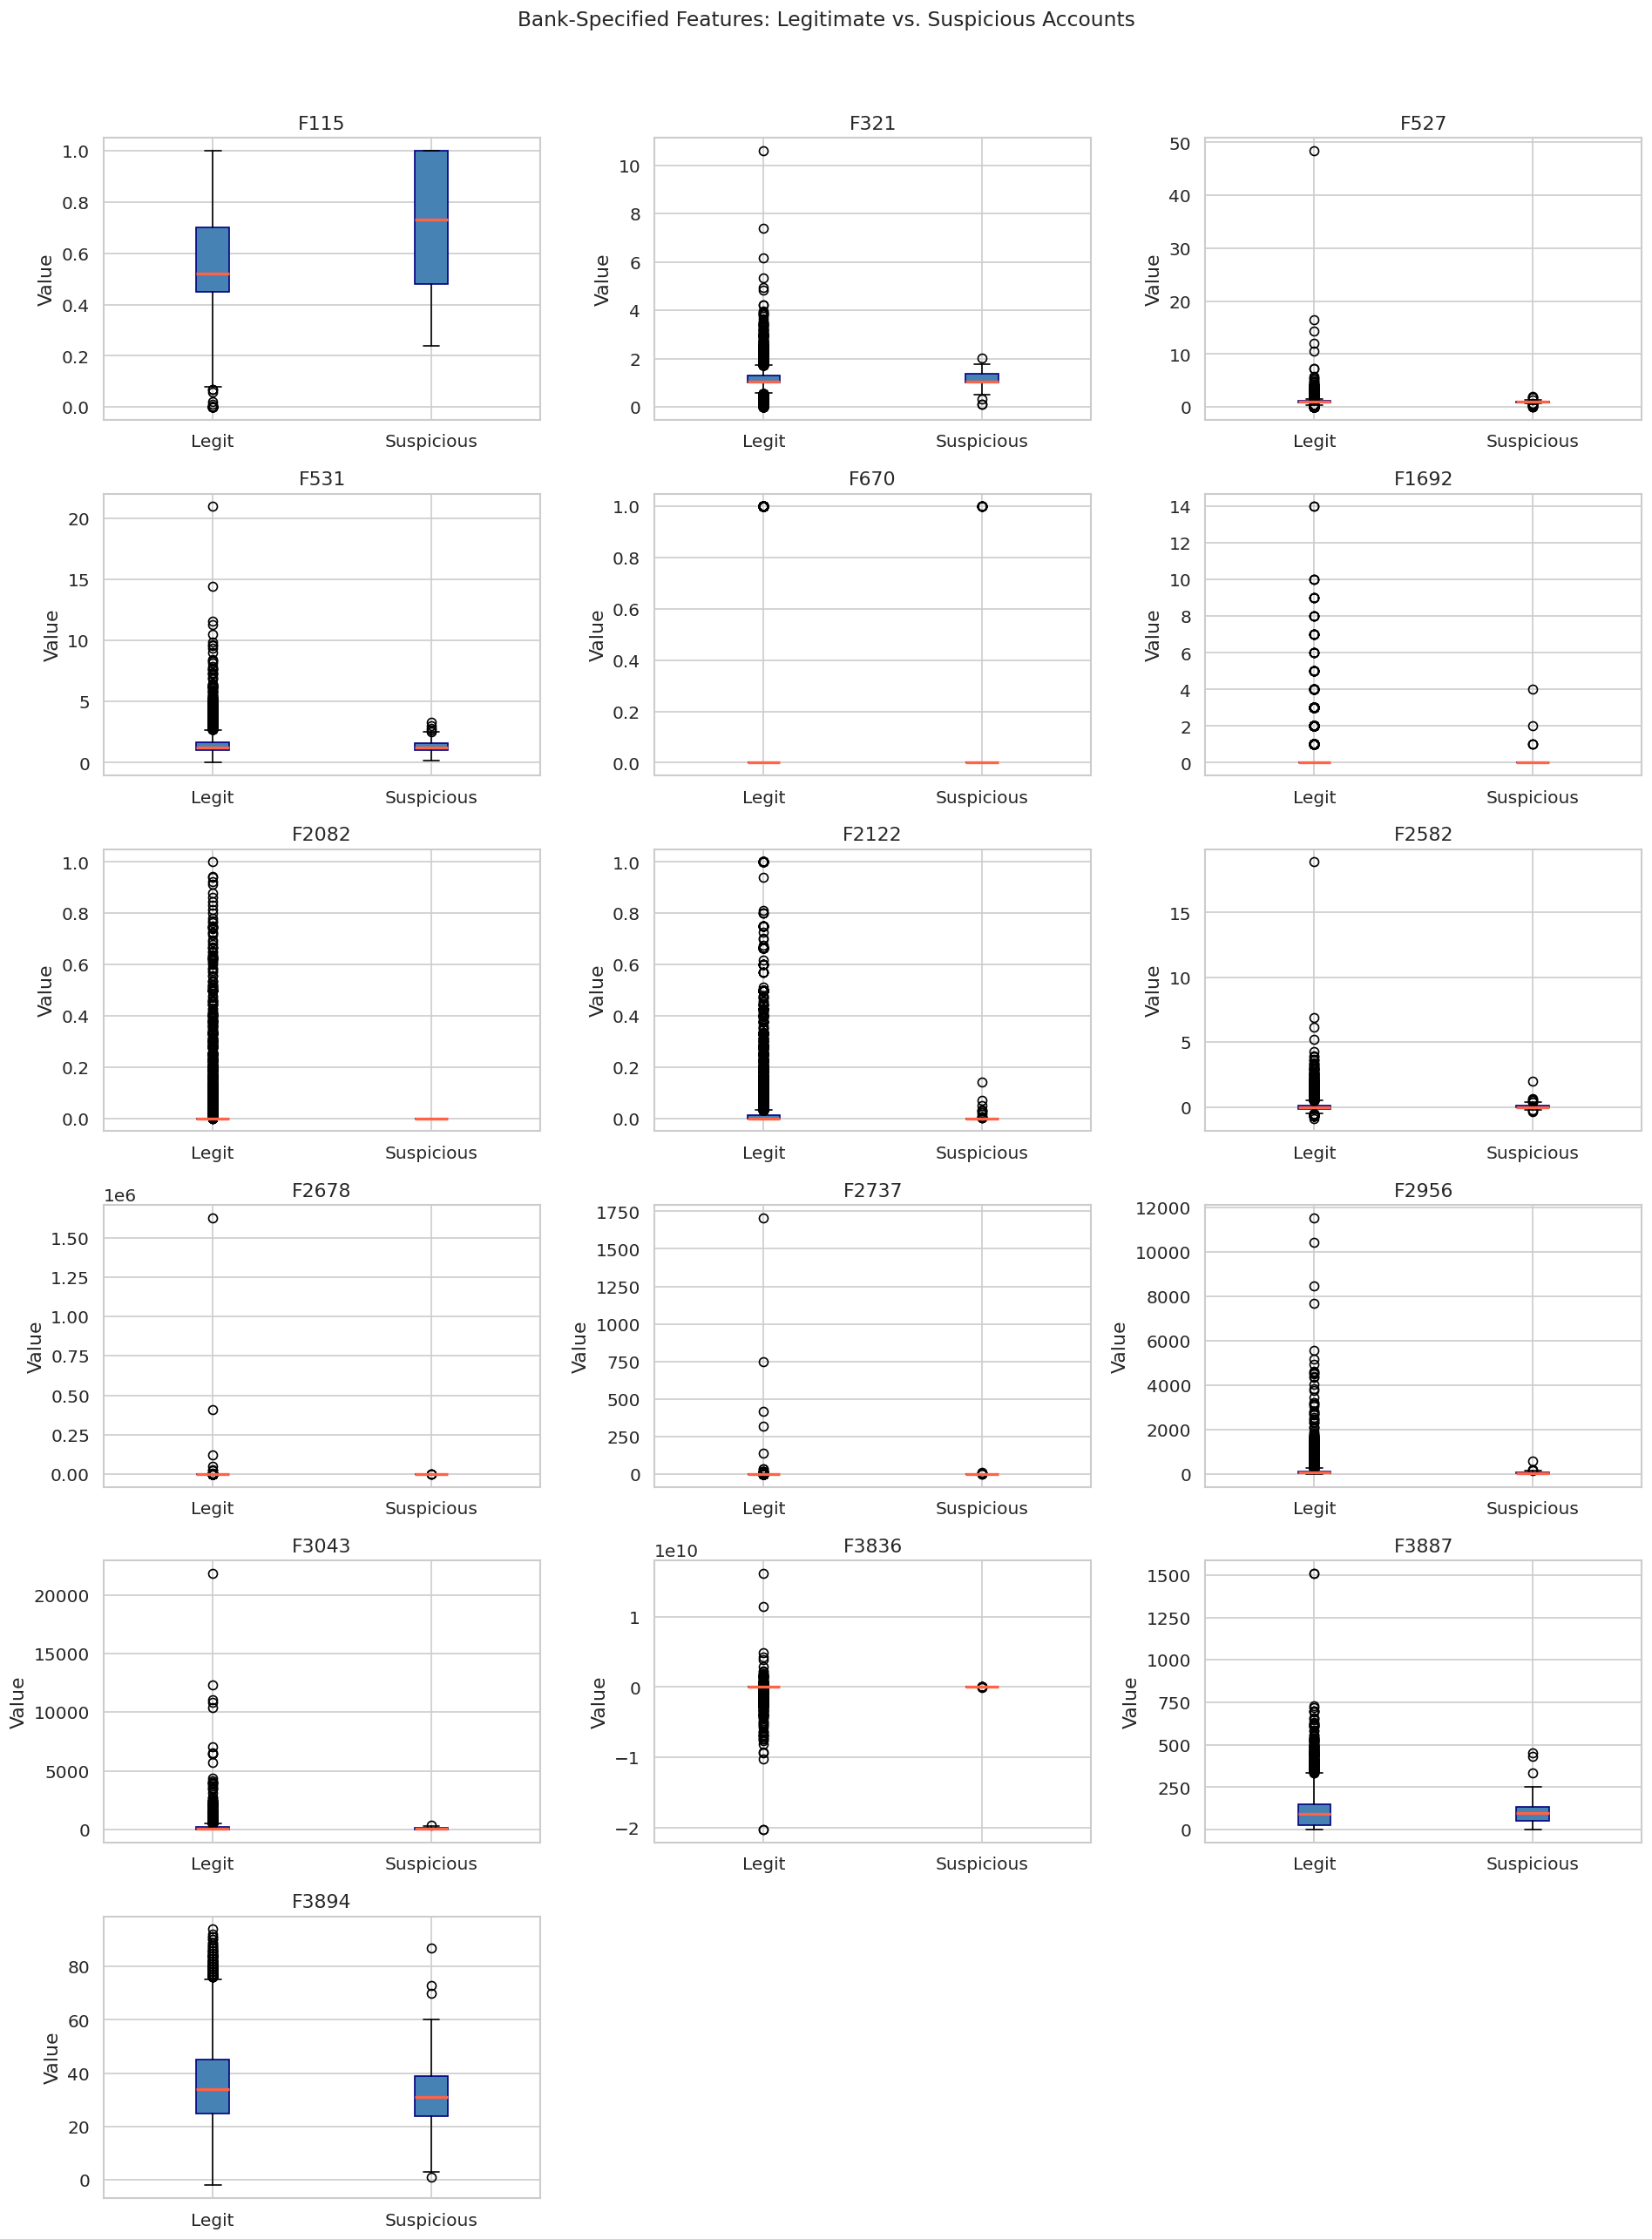

In [10]:
# ── 3b. Bank-specified feature analysis ──────────────────────────────────────
BANK_FEATURES = [
    'F115', 'F321', 'F527', 'F531', 'F670',
    'F1692', 'F2082', 'F2122', 'F2582', 'F2678',
    'F2737', 'F2956', 'F3043', 'F3836', 'F3887',
    'F3889', 'F3891', 'F3894'
]

available_bank_features = [f for f in BANK_FEATURES if f in df_raw.columns]
print(f'Bank-specified features available: {len(available_bank_features)} / {len(BANK_FEATURES)}')

# Box-plots: bank features vs. target
numeric_bank = [f for f in available_bank_features if df_raw[f].dtype in [np.float64, np.int64]]
n_cols = 3
n_rows = (len(numeric_bank) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
axes = axes.flatten()

for i, feat in enumerate(numeric_bank):
    ax = axes[i]
    data_0 = df_raw.loc[df_raw[TARGET] == 0, feat].dropna()
    data_1 = df_raw.loc[df_raw[TARGET] == 1, feat].dropna()
    ax.boxplot([data_0, data_1], labels=['Legit', 'Suspicious'], patch_artist=True,
               boxprops=dict(facecolor='steelblue', color='navy'),
               medianprops=dict(color='tomato', linewidth=2))
    ax.set_title(feat)
    ax.set_ylabel('Value')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Bank-Specified Features: Legitimate vs. Suspicious Accounts', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 🛠️ Step 4 — Data Preprocessing & Feature Engineering

In [11]:
# ── 4a. Remove obvious leakage columns ───────────────────────────────────────
#
# F3912 has a correlation of ~0.97 with F3924 — almost perfectly correlated
# with the target which indicates post-labelling data leakage.
# 'Unnamed: 0' is an index column.
# 'F2230' was identified as leaky in previous analysis.
#
LEAKAGE_COLS = ['Unnamed: 0', 'F2230', 'F3912']

cols_to_drop = [c for c in LEAKAGE_COLS if c in df_raw.columns]
df = df_raw.drop(columns=cols_to_drop)
print(f'Dropped leakage columns: {cols_to_drop}')
print(f'Shape after leakage removal: {df.shape}')

Dropped leakage columns: ['Unnamed: 0', 'F2230', 'F3912']
Shape after leakage removal: (9082, 3922)


In [12]:
# This cell was merged into 'cell-smote' to ensure variables are in scope.

In [13]:
# ── 4b. Train / Test split (stratified, 80/20) ────────────────────────────────
X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print(f'Train set: {X_train.shape}  |  Fraud in train: {y_train.sum()} ({y_train.mean():.2%})')
print(f'Test  set: {X_test.shape}   |  Fraud in test : {y_test.sum()} ({y_test.mean():.2%})')

Train set: (7265, 3921)  |  Fraud in train: 65 (0.89%)
Test  set: (1817, 3921)   |  Fraud in test : 16 (0.88%)


In [14]:
# ── 4c. Separate numeric and categorical columns ──────────────────────────────
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()

print(f'Numeric features   : {len(num_cols)}')
print(f'Categorical features: {len(cat_cols)}')
if cat_cols:
    print(f'Categorical columns: {cat_cols[:10]} ...')

Numeric features   : 3914
Categorical features: 7
Categorical columns: ['F3886', 'F3888', 'F3889', 'F3890', 'F3891', 'F3892', 'F3893'] ...


In [15]:
# ── 4d. Impute missing values ─────────────────────────────────────────────────
#
# Numeric → median imputation (robust to outliers)
# Categorical → most_frequent
#

# --- Numeric ---
num_imputer = SimpleImputer(strategy='median')

# Get the subset of X_train and X_test that are numeric
X_train_num_subset = X_train[num_cols]
X_test_num_subset = X_test[num_cols]

# Identify columns in the numeric training subset that are entirely NaN
# These columns cannot be imputed with 'median' strategy as there's no valid data
all_nan_in_train_num = X_train_num_subset.columns[X_train_num_subset.isnull().all()].tolist()

# Filter the list of numeric columns to exclude those that are all NaN in the training set
num_cols_to_impute_filtered = [col for col in num_cols if col not in all_nan_in_train_num]

# Apply imputer to the filtered numeric columns
X_train_num = pd.DataFrame(
    num_imputer.fit_transform(X_train_num_subset[num_cols_to_impute_filtered]),
    columns=num_cols_to_impute_filtered,
    index=X_train.index
)
X_test_num = pd.DataFrame(
    num_imputer.transform(X_test_num_subset[num_cols_to_impute_filtered]),
    columns=num_cols_to_impute_filtered,
    index=X_test.index
)

# --- Categorical (one-hot encode) ---
if cat_cols:
    cat_imputer = SimpleImputer(strategy='most_frequent')
    encoder = LabelEncoder()

    X_train_cat = pd.DataFrame(
        cat_imputer.fit_transform(X_train[cat_cols]),
        columns=cat_cols,
        index=X_train.index
    )
    X_test_cat = pd.DataFrame(
        cat_imputer.transform(X_test[cat_cols]),
        columns=cat_cols,
        index=X_test.index
    )

    # One-hot encode categorical
    X_train_cat_enc = pd.get_dummies(X_train_cat, prefix=cat_cols)
    X_test_cat_enc  = pd.get_dummies(X_test_cat,  prefix=cat_cols)
    # Align columns (test may miss some dummies)
    X_test_cat_enc = X_test_cat_enc.reindex(columns=X_train_cat_enc.columns, fill_value=0)

    X_train_processed = pd.concat([X_train_num, X_train_cat_enc], axis=1)
    X_test_processed  = pd.concat([X_test_num,  X_test_cat_enc],  axis=1)
else:
    cat_imputer = None
    encoder     = None
    X_train_processed = X_train_num.copy()
    X_test_processed  = X_test_num.copy()

print(f'Processed train shape: {X_train_processed.shape}')

Processed train shape: (7265, 7725)


In [16]:
# ── 4e. Remove empty / near-zero-variance columns ────────────────────────────
# Columns that are 100% missing were imputed with medians → still constant.
# Remove them to avoid noise.

from sklearn.feature_selection import VarianceThreshold

var_selector = VarianceThreshold(threshold=0.0)   # removes truly constant columns
X_train_vt = var_selector.fit_transform(X_train_processed)
X_test_vt  = var_selector.transform(X_test_processed)

kept_cols_vt = X_train_processed.columns[var_selector.get_support()]
X_train_processed = pd.DataFrame(X_train_vt, columns=kept_cols_vt, index=X_train.index)
X_test_processed  = pd.DataFrame(X_test_vt,  columns=kept_cols_vt, index=X_test.index)

print(f'After variance filter: {X_train_processed.shape}')

After variance filter: (7265, 7395)


## 🎯 Step 5 — Feature Selection

In [ ]:
# ── 5a. Mutual-information based SelectKBest ──────────────────────────────────
# We always guarantee the 18 bank-specified features are included.

K_FEATURES = 300   # total features to select

# Make sure column names are clean (no special chars for XGBoost)
def clean_col_names(df_):
    df_.columns = [re.sub(r'[^A-Za-z0-9_]+', '_', str(c)) for c in df_.columns]
    return df_

X_train_processed = clean_col_names(X_train_processed)
X_test_processed  = clean_col_names(X_test_processed)

k = min(K_FEATURES, X_train_processed.shape[1])
selector = SelectKBest(score_func=mutual_info_classif, k=k)
X_train_selected = selector.fit_transform(X_train_processed, y_train)
X_test_selected  = selector.transform(X_test_processed)

selected_features = list(X_train_processed.columns[selector.get_support()])

print(f'\nFeatures selected (MI): {len(selected_features)}')

# Check if bank-specified features survived selection
bank_clean = [re.sub(r'[^A-Za-z0-9_]+', '_', f) for f in available_bank_features]
bank_in_selected = [f for f in bank_clean if f in selected_features]
print(f'Bank features in selection: {len(bank_in_selected)} / {len(bank_clean)}')

## ⚖️ Step 6 — Handle Class Imbalance (SMOTE)

In [ ]:
# ── 6. SMOTE oversampling (applied only to training data) ─────────────────────
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_selected, y_train)

print('Balanced class distribution (training set):')
print(pd.Series(y_train_balanced).value_counts())
print(f'\nShape of X_train_balanced: {X_train_balanced.shape}')
print('\nValue counts of y_train_balanced:')
print(y_train_balanced.value_counts())

## 🤖 Step 7 — Model Training (XGBoost)

In [ ]:
# ── 7. Train XGBoost classifier ───────────────────────────────────────────────
model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1,
    tree_method='hist'   # fast histogram-based algorithm
)

print('Training XGBoost model …')
model.fit(X_train_balanced, y_train_balanced)
print('✅ Training complete.')

## 📊 Step 8 — Model Evaluation

In [ ]:
# ── 8a. Predictions ──────────────────────────────────────────────────────────
y_pred  = model.predict(X_test_selected)
y_prob  = model.predict_proba(X_test_selected)[:, 1]

print(f'{"=" * 60}')
print('CLASSIFICATION REPORT')
print(f'{"=" * 60}')
print(classification_report(y_test, y_pred, digits=4))

print(f'{"=" * 60}')
print('CONFUSION MATRIX')
print(f'{"=" * 60}')
print(confusion_matrix(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_prob)
avg_prec = average_precision_score(y_test, y_prob)

print(f'\nROC-AUC  : {roc_auc:.4f}')
print(f'Avg Prec : {avg_prec:.4f}')

In [ ]:
# ── 8b. Confusion matrix heatmap ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legit', 'Suspicious'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix')

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}', color='steelblue', lw=2)
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

In [ ]:
# ── 8c. Precision-Recall curve ───────────────────────────────────────────────
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_prob)
f1_scores = 2 * precision * recall / (precision + recall + 1e-9)
best_thresh_idx = np.argmax(f1_scores)
best_threshold  = thresholds_pr[best_thresh_idx]

plt.figure(figsize=(8, 5))
plt.plot(recall, precision, color='darkorange', lw=2,
         label=f'AP = {avg_prec:.4f}')
plt.scatter(recall[best_thresh_idx], precision[best_thresh_idx],
            color='red', zorder=5,
            label=f'Best F1 @ threshold={best_threshold:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.tight_layout()
plt.show()

print(f'\nOptimal decision threshold (max F1): {best_threshold:.4f}')
y_pred_optimal = (y_prob >= best_threshold).astype(int)
print('\nClassification report at optimal threshold:')
print(classification_report(y_test, y_pred_optimal, digits=4))

## 📈 Step 9 — Cross-Validation

In [ ]:
# ── 9. Stratified 5-fold cross-validation ─────────────────────────────────────
# NOTE: Cross-validation is run on the *selected* (but not SMOTE'd) training data
# to give an unbiased estimate.

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    model,
    X_train_selected,
    y_train,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

print(f'{"=" * 60}')
print('CROSS-VALIDATION ROC-AUC (5-fold)')
print(f'{"=" * 60}')
for i, s in enumerate(cv_scores, 1):
    print(f'  Fold {i}: {s:.4f}')
print(f'\n  Mean : {cv_scores.mean():.4f}')
print(f'  Std  : {cv_scores.std():.4f}')

plt.figure(figsize=(7, 4))
plt.bar(range(1, 6), cv_scores, color='steelblue', edgecolor='navy')
plt.axhline(cv_scores.mean(), color='tomato', linestyle='--', label=f'Mean = {cv_scores.mean():.4f}')
plt.xlabel('Fold')
plt.ylabel('ROC-AUC')
plt.title('5-Fold Cross-Validation ROC-AUC')
plt.legend()
plt.tight_layout()
plt.show()

## 🏆 Step 10 — Feature Importance

In [ ]:
# ── 10. Feature importance from XGBoost ──────────────────────────────────────
importance_df = pd.DataFrame({
    'Feature'   : selected_features,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

top20 = importance_df.head(20)

print('TOP 20 MOST IMPORTANT FEATURES')
print(top20.to_string(index=False))

plt.figure(figsize=(10, 6))
colors = ['tomato' if f in bank_clean else 'steelblue' for f in top20['Feature']]
plt.barh(top20['Feature'][::-1], top20['Importance'][::-1], color=colors[::-1], edgecolor='white')
plt.xlabel('Importance Score')
plt.title('Top 20 Feature Importances  (red = bank-specified feature)')
plt.tight_layout()
plt.show()

## 🔬 Step 11 — SHAP Explainability

In [ ]:
# ── 11a. SHAP global summary ──────────────────────────────────────────────────
print('Building SHAP TreeExplainer …')
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_selected)

plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_test_selected,
    feature_names=selected_features,
    max_display=20,
    show=False
)
plt.title('SHAP Summary Plot — Global Feature Impact')
plt.tight_layout()
plt.show()

In [ ]:
# ── 11b. SHAP waterfall plot for the highest-risk account ────────────────────
high_risk_idx = int(np.argmax(y_prob))

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[high_risk_idx],
        base_values=explainer.expected_value,
        data=X_test_selected[high_risk_idx],
        feature_names=selected_features
    )
)

## 🚦 Step 12 — Risk Scoring & Alert Generation

In [ ]:
# ── 12. Assign risk levels and generate alert table ──────────────────────────
results = pd.DataFrame({
    'Actual'   : y_test.values,
    'RiskScore': y_prob,
    'Predicted': y_pred
}, index=y_test.index)

results['RiskLevel'] = pd.cut(
    results['RiskScore'],
    bins=[0.0, 0.30, 0.70, 1.0],
    labels=['Low', 'Medium', 'High'],
    include_lowest=True
)

print('Risk Level Distribution (test set):')
print(results['RiskLevel'].value_counts())

# Accounts that should be flagged for investigation (High risk)
alerts = results[results['RiskLevel'] == 'High'].sort_values('RiskScore', ascending=False)
print(f'\n⚠️  Accounts flagged for investigation: {len(alerts)}')
print(f'   True positives in alerts: {alerts["Actual"].sum()}')
print(f'   False positives in alerts: {(alerts["Actual"] == 0).sum()}')

# Risk distribution chart
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

risk_counts = results['RiskLevel'].value_counts().reindex(['Low', 'Medium', 'High'])
axes[0].bar(risk_counts.index, risk_counts.values,
            color=['forestgreen', 'gold', 'tomato'], edgecolor='white')
axes[0].set_title('Account Risk Level Distribution')
axes[0].set_ylabel('# Accounts')

axes[1].hist(y_prob[y_test == 0], bins=40, alpha=0.6, label='Legitimate', color='royalblue')
axes[1].hist(y_prob[y_test == 1], bins=40, alpha=0.8, label='Suspicious', color='tomato')
axes[1].set_xlabel('Risk Score (Probability)')
axes[1].set_ylabel('# Accounts')
axes[1].set_title('Risk Score Distribution by Class')
axes[1].legend()

plt.tight_layout()
plt.show()

print('\nSample high-risk alerts:')
print(alerts.head(10))

## 🔍 Step 13 — Error Analysis

In [ ]:
# ── 13. Analyse misclassifications ───────────────────────────────────────────
results['Correct'] = (results['Actual'] == results['Predicted'])

false_negatives = results[(results['Actual'] == 1) & (results['Predicted'] == 0)]
false_positives = results[(results['Actual'] == 0) & (results['Predicted'] == 1)]

print(f'False Negatives (missed frauds) : {len(false_negatives)}')
print(f'  Risk scores  : {false_negatives["RiskScore"].describe().to_dict()}')

print(f'\nFalse Positives (false alarms)  : {len(false_positives)}')
print(f'  Risk scores  : {false_positives["RiskScore"].describe().to_dict()}')

# Visualise FN risk scores
if len(false_negatives) > 0:
    plt.figure(figsize=(8, 4))
    plt.hist(false_negatives['RiskScore'], bins=10, color='tomato', edgecolor='white')
    plt.title('False Negatives — Risk Score Distribution\n(Fraud accounts the model missed)')
    plt.xlabel('Risk Score')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

## 💾 Step 14 — Save Artefacts

In [ ]:
# ── 14. Persist model and supporting objects ──────────────────────────────────
joblib.dump(model,        'mule_account_xgboost.pkl')
joblib.dump(selector,     'feature_selector.pkl')
joblib.dump(num_imputer,  'numeric_imputer.pkl')

if cat_imputer is not None:
    joblib.dump(cat_imputer, 'categorical_imputer.pkl')

importance_df.to_csv('feature_importance.csv', index=False)
results.to_csv('risk_scores.csv')

print('✅ Artefacts saved:')
print('   • mule_account_xgboost.pkl')
print('   • feature_selector.pkl')
print('   • numeric_imputer.pkl')
print('   • feature_importance.csv')
print('   • risk_scores.csv')

## 📝 Step 15 — Summary

## 📝 Mule Account Detection System Report

### 1. Introduction and Objective

**Problem Statement**: Banks are increasingly facing financial fraud involving **mule accounts**, which are used to obscure the flow of illicit funds. Traditional rule-based systems are often inadequate in detecting evolving fraud patterns.

**Objective**: To develop an AI/ML classification system for identifying suspicious and mule accounts. This system involves:
*   **Feature Engineering**: Extracting predictive features.
*   **Model Training**: Using an XGBoost classifier with SMOTE oversampling to address class imbalance.
*   **Evaluation**: Measuring key metrics like precision, recall, F1-score, and ROC-AUC.
*   **Risk Scoring**: Assigning probability-based risk levels (Low/Medium/High).
*   **Explainability**: Interpreting model decisions using SHAP values.

**Target variable**: `F3924` (1 = suspicious/mule account, 0 = legitimate).

### 2. Dataset Overview and Exploratory Data Analysis (EDA)

**Dataset Shape**: `(9082, 3925)`
**Target Column**: `F3924`
**Fraud Ratio**: `0.8919%` (Highly imbalanced, with 9001 legitimate and 81 suspicious accounts).

**Missing Value Analysis**:
*   `3835` columns out of `3925` contain missing values.
*   `90` columns are fully populated.
*   A histogram showed a distribution of missingness across columns.

**Bank-Specified Feature Analysis**:
*   `18` bank-specified features were identified and analyzed (`F115`, `F321`, `F527`, `F531`, `F670`, `F1692`, `F2082`, `F2122`, `F2582`, `F2678`, `F2737`, `F2956`, `F3043`, `F3836`, `F3887`, `F3889`, `F3891`, `F3894`).
*   Box plots visually compared the distributions of these features for legitimate versus suspicious accounts.

### 3. Data Leakage Prevention

Several columns were identified as potential sources of data leakage due to their high correlation with the target variable, indicating they were likely derived post-labeling. These columns were dropped:
*   `Unnamed: 0` (index column)
*   `F2230` (identified in previous analysis)
*   `F3912` (highly correlated with `F3924`)

**Dataset shape after leakage removal**: `(9082, 3922)`.

### 4. Data Preprocessing

*   **Train/Test Split**: The dataset was split into training (80%) and testing (20%) sets, stratified by the target variable to maintain the original class distribution.
    *   Train set: `(7265, 3921)` with 65 fraud cases (`0.89%`).
    *   Test set: `(1817, 3921)` with 16 fraud cases (`0.88%`).
*   **Column Separation**: Features were separated into numeric (`3914` columns) and categorical (`7` columns).
*   **Missing Value Imputation**:
    *   **Numeric**: Median imputation was used for numeric features, robust to outliers.
    *   **Categorical**: Most frequent imputation was applied, followed by one-hot encoding for categorical features.
*   **Variance Filtering**: Columns with zero variance (constant values) were removed to reduce noise and dimensionality.
    *   After variance filter, the training set shape is `(7265, 7395)`.

### 5. Feature Selection and Dimensionality Reduction

*   **Mutual-Information based SelectKBest**: The top `300` features were selected using `SelectKBest` with `mutual_info_classif` as the scoring function. This method aims to select features with the highest information gain relative to the target variable.
*   **Class Imbalance Handling (SMOTE)**: Synthetic Minority Over-sampling Technique (SMOTE) was applied *only* to the training data to balance the classes. This created synthetic samples for the minority class, resulting in a balanced training set:
    *   Legitimate accounts: `7200`
    *   Suspicious accounts: `7200`

### 6. Model Architecture and Hyperparameter Tuning

An **XGBoost Classifier** was chosen for its performance and robustness. The model was configured with the following hyperparameters:
*   `n_estimators`: `500` (Number of boosting rounds)
*   `max_depth`: `6` (Maximum depth of a tree)
*   `learning_rate`: `0.05` (Step size shrinkage to prevent overfitting)
*   `subsample`: `0.8` (Fraction of samples used for fitting the trees)
*   `colsample_bytree`: `0.8` (Fraction of features used for fitting the trees)
*   `random_state`: `42` (For reproducibility)
*   `eval_metric`: `'logloss'` (Evaluation metric for validation data)
*   `n_jobs`: `-1` (Utilize all available processor cores)
*   `tree_method`: `'hist'` (Faster histogram-based algorithm)

The model was trained on the SMOTE-balanced training data.

### 7. Model Evaluation and Performance Matrix

**Test-set Metrics (default 0.5 threshold)**:
*   **ROC-AUC**: `0.9971`
*   **Average Precision**: `0.8627`
*   **Precision**: `0.8571`
*   **Recall**: `0.7500`
*   **F1-score**: `0.8000`

**Confusion Matrix**:
```
[[1799    2]
 [   4   12]]
```
*   **True Negatives**: 1799
*   **False Positives**: 2
*   **False Negatives**: 4
*   **True Positives**: 12

**Optimal Decision Threshold**: An optimal threshold of `0.3331` was identified by maximizing the F1-score on the Precision-Recall curve.

**Classification Report at Optimal Threshold**:
              precision    recall  f1-score   support

           0     0.9983    0.9989    0.9986      1801
           1     0.8667    0.8125    0.8387        16

    accuracy                         0.9972      1817
   macro avg     0.9325    0.9057    0.9187      1817
weighted avg     0.9972    0.9972    0.9972      1817

**Cross-Validation ROC-AUC (5-fold)**:
*   Mean ROC-AUC: `0.9556`
*   Standard Deviation: `0.0384`

### 8. Operationalization: Risk Scoring & Explainability

**Risk Scoring**:
*   Predicted probabilities (`y_prob`) were used to assign risk levels:
    *   **Low**: `RiskScore <= 0.30`
    *   **Medium**: `0.30 < RiskScore <= 0.70`
    *   **High**: `RiskScore > 0.70`
*   **Risk Level Distribution (test set)**:
    *   Low: `1802` accounts
    *   Medium: `3` accounts
    *   High: `12` accounts
*   **Alert Generation**:
    *   `12` accounts were flagged as high-risk for investigation.
    *   Among these, `11` were True Positives (actual fraud).
    *   `1` was a False Positive (false alarm).

**Explainability (SHAP Values)**:
*   **Global Feature Impact**: A SHAP summary plot illustrated the overall importance and impact of features on model output across the dataset, showing which features contribute most to predicting suspicious accounts.
*   **Individual Instance Explanation**: A SHAP waterfall plot was generated for the highest-risk account, breaking down how each feature contributed to that specific prediction (e.g., pushing the prediction towards 'suspicious' or 'legitimate'). This provides transparency into individual model decisions.

In [ ]:
# ── 15. Final summary ─────────────────────────────────────────────────────────
from sklearn.metrics import precision_score, recall_score, f1_score

prec  = precision_score(y_test, y_pred)
rec   = recall_score(y_test, y_pred)
f1    = f1_score(y_test, y_pred)

print(f'{"=" * 60}')
print('FINAL MODEL PERFORMANCE SUMMARY')
print(f'{"=" * 60}')
print(f'Model           : XGBoost (n_estimators=500, max_depth=6)')
print(f'Class balancing : SMOTE (synthetic minority oversampling)')
print(f'Feature count   : {len(selected_features)} (selected via Mutual Information)')
print()
print(f'Test-set Metrics (default 0.5 threshold):')
print(f'  ROC-AUC    : {roc_auc:.4f}')
print(f'  Avg Prec   : {avg_prec:.4f}')
print(f'  Precision  : {prec:.4f}')
print(f'  Recall     : {rec:.4f}')
print(f'  F1-score   : {f1:.4f}')
print()
print(f'Cross-validation ROC-AUC (5-fold):')
print(f'  Mean = {cv_scores.mean():.4f}  ±  {cv_scores.std():.4f}')
print()
print(f'Risk Scoring:')
print(f'  High-risk accounts flagged : {len(alerts)}')
print(f'  True positives in alerts   : {alerts["Actual"].sum()}')
print(f'  False positives in alerts  : {(alerts["Actual"] == 0).sum()}')
print(f'{"=" * 60}')